In [4]:
import os
import sys
import pyarrow as pa
from pathlib import Path
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import TimeSeriesSplit
from tqdm import tqdm
from joblib import Parallel, delayed
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
sys.path.insert(0, "..")
from paths import resolve

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
_NCPU = os.cpu_count() or 1
pa.set_cpu_count(_NCPU)
pa.set_io_thread_count(_NCPU)
os.environ["NUMEXPR_MAX_THREADS"] = str(_NCPU)
os.environ["NUMEXPR_NUM_THREADS"] = str(_NCPU)
os.environ.setdefault("OMP_NUM_THREADS", str(_NCPU))
os.environ.setdefault("OPENBLAS_NUM_THREADS", str(_NCPU))
os.environ.setdefault("MKL_NUM_THREADS", str(_NCPU))
print(f"Running with {_NCPU} CPU cores | pyarrow {pa.__version__}", flush=True)

Running with 8 CPU cores | pyarrow 24.0.0


Variables

In [5]:
%run 0_variables.ipynb

Correlation matrix

In [6]:
_stem = Path(os.environ['FEATURE_DATASET']).stem
feature_data = pd.read_parquet(
    resolve(f"3_Features select/Selected_features/{os.environ['TARGET']}_feature_data_{_stem}.parquet")
)

def add_windows():
    HORIZONS_PER_WINDOW = int(os.environ["HORIZONS_PER_WINDOW"])
    OUTPUT_RESOLUTION = int(os.environ["OUTPUT_RESOLUTION"])

    _fd = feature_data
    horizon_cols = [c for c in _fd.columns if c.startswith("h") and c[1:].isdigit()]
    n_windows = len(horizon_cols) // HORIZONS_PER_WINDOW
    mi_df = _fd.set_index("feature")[horizon_cols]

    window_selections = {}
    window_mi_matrices = {}

    for w in range(n_windows):
        start_h = w * HORIZONS_PER_WINDOW
        end_h = start_h + HORIZONS_PER_WINDOW
        win_cols = horizon_cols[start_h:end_h]

        start_min = start_h * OUTPUT_RESOLUTION
        end_min = end_h * OUTPUT_RESOLUTION
        label = f"{start_min // 60}–{end_min // 60}h"

        win_mi = mi_df[win_cols]
        window_mi_matrices[label] = win_mi
        window_selections[label] = win_mi.mean(axis=1).sort_values(ascending=False).index.tolist()

    return window_selections, window_mi_matrices

window_selections, window_mi_matrices = add_windows()


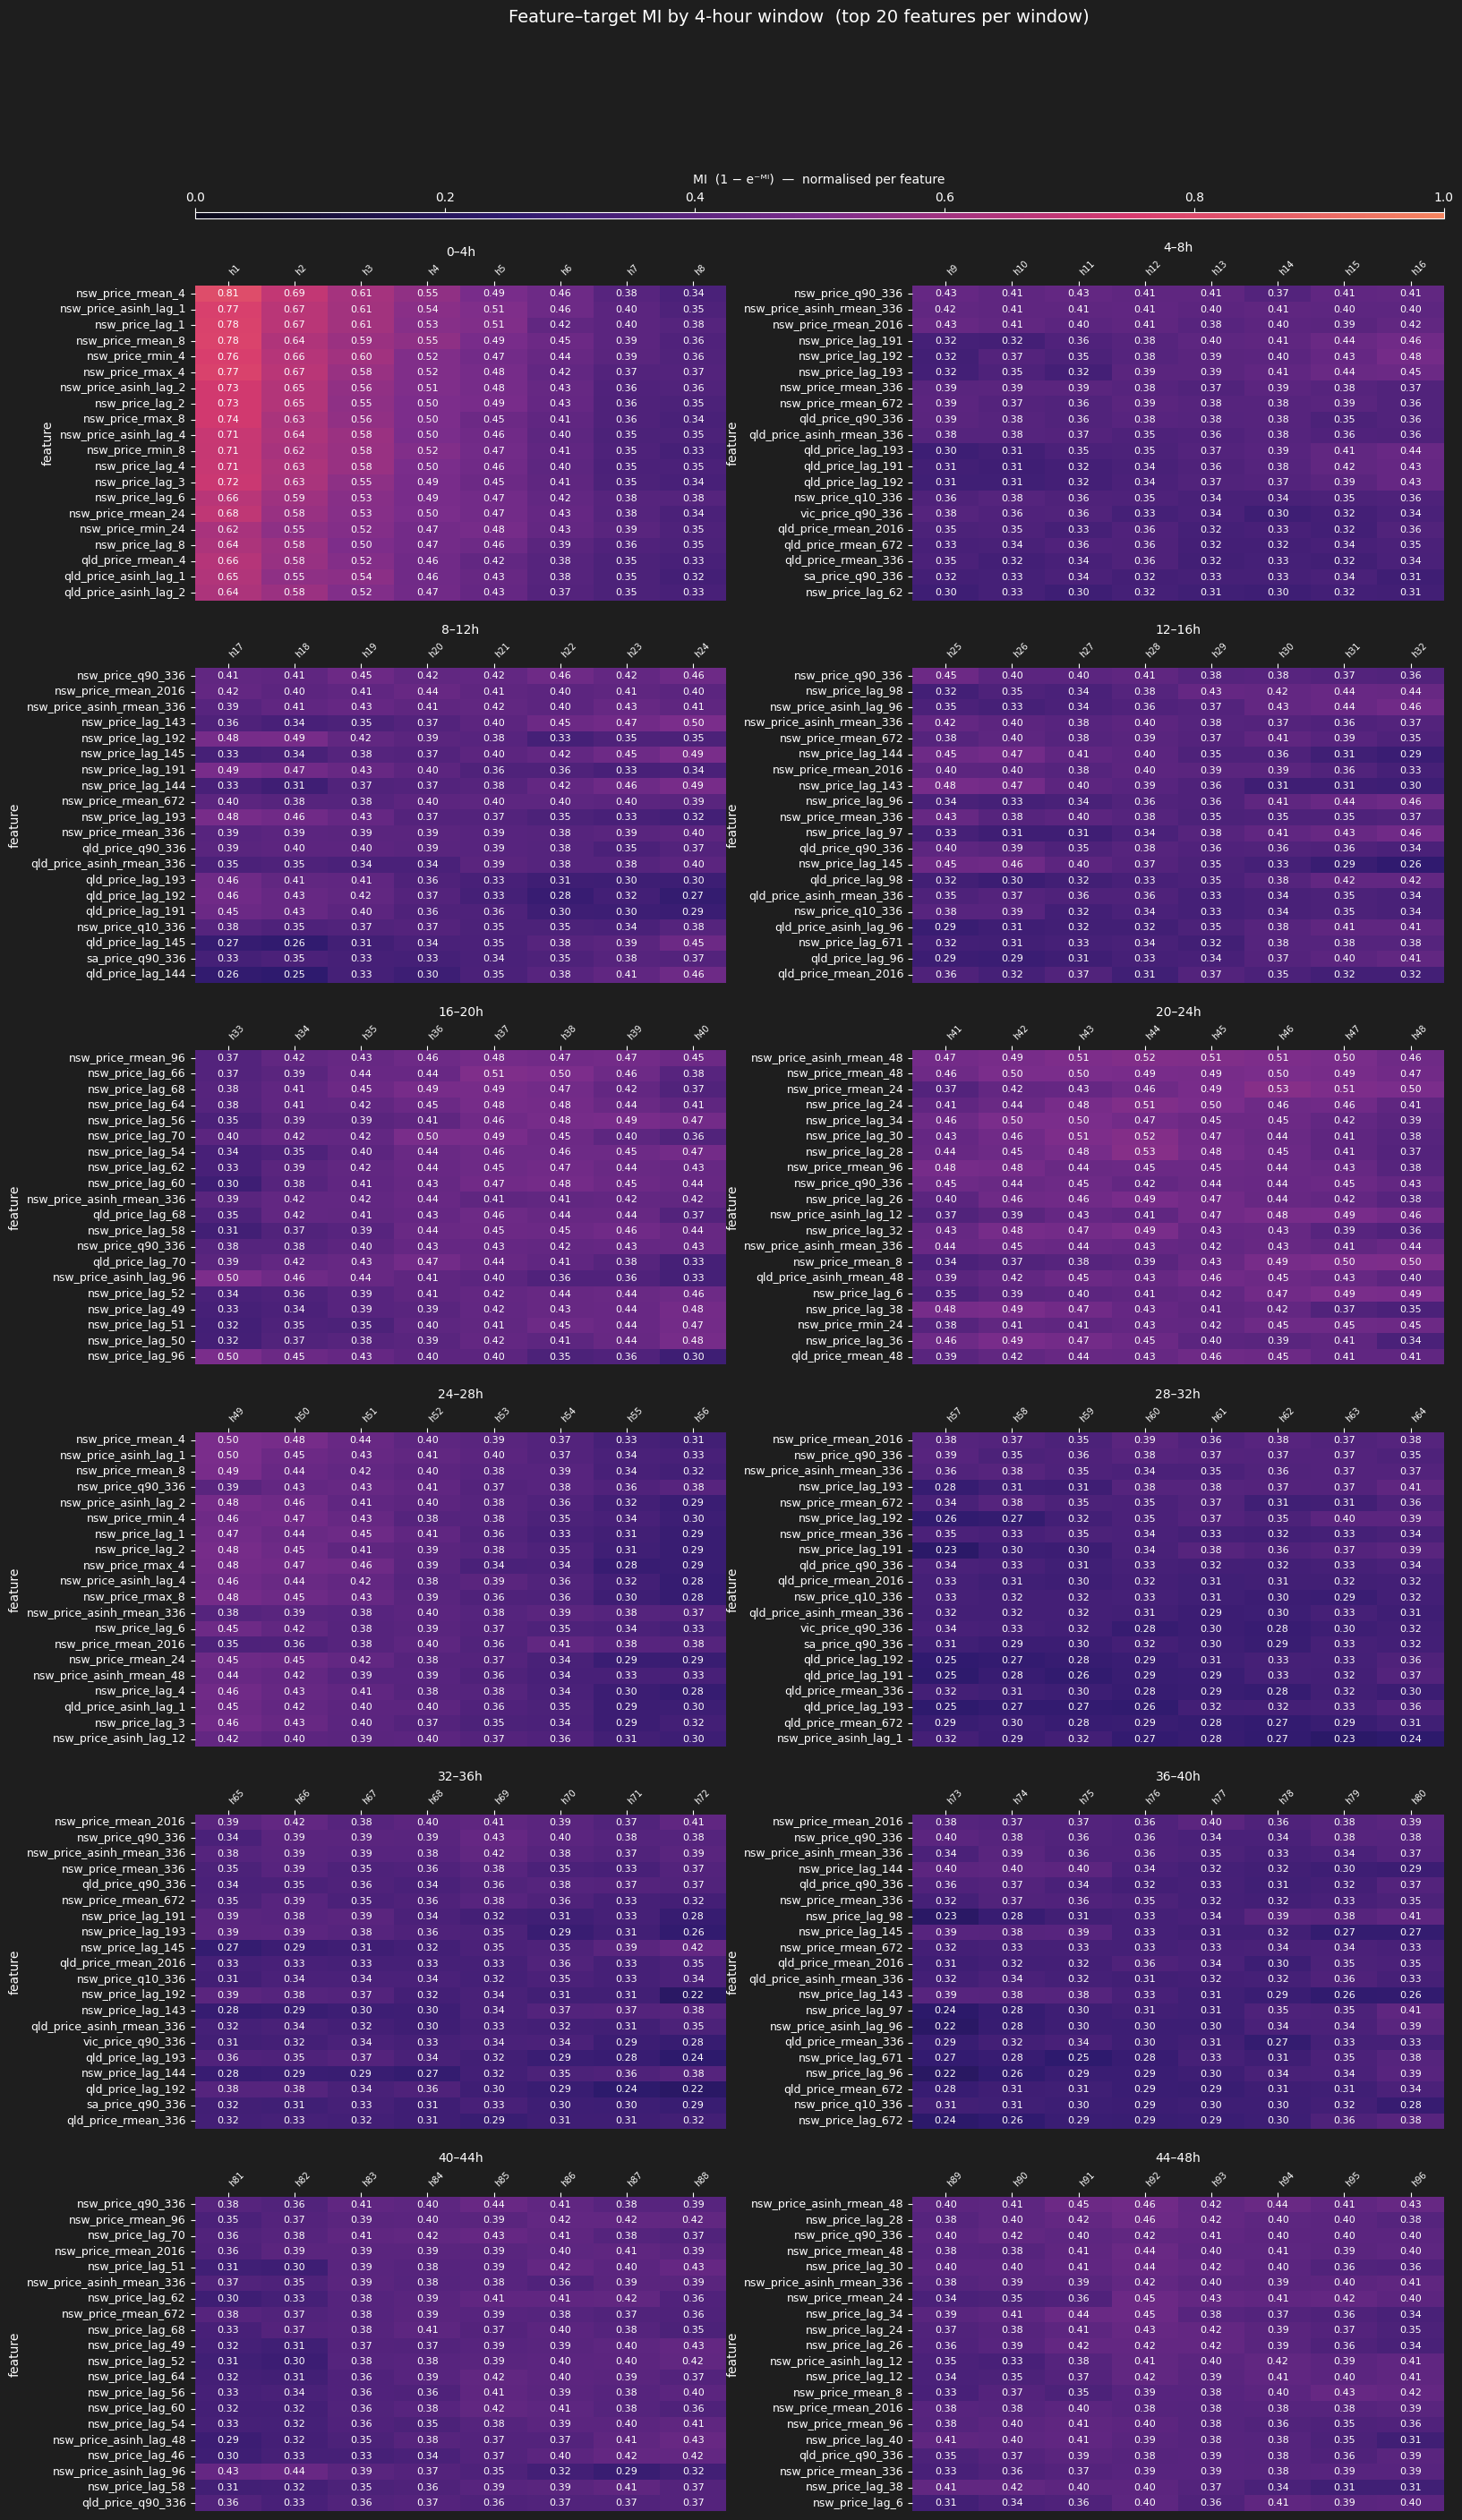

In [7]:
def mi_matrix_facets(window_selections: dict, window_mi_matrices: dict, top_n: int = 20, ncols: int = 4):
    """All window MI heatmaps in one faceted figure with a shared colorbar."""
    labels = list(window_selections.keys())
    nrows  = (len(labels) + ncols - 1) // ncols

    _cmap = LinearSegmentedColormap.from_list(
        "mi_vibrant", ["#0a0a1a", "#2e1a6e", "#7b2d8b", "#d63a6e", "#f4845f"], N=256
    )

    # Pre-normalise each window's MI matrix, sorted by window MI, top_n features
    win_norms = {}
    for label, feats in window_selections.items():
        mi_win = window_mi_matrices[label].loc[feats]
        mi_win = mi_win.loc[mi_win.mean(axis=1).sort_values(ascending=False).index]
        win_norms[label] = (1 - np.exp(-mi_win)).head(top_n)

    col_w   = 9
    row_h   = max(3.5, top_n * 0.27)
    CBAR_H  = 0.1
    TITLE_H = 0.001   # extra space at top for the suptitle

    with plt.style.context("dark_background"):
        fig = plt.figure(figsize=(col_w * ncols, row_h * nrows + CBAR_H + TITLE_H))
        fig.patch.set_facecolor("#1e1e1e")

        gs = fig.add_gridspec(
            nrows + 1, ncols,
            height_ratios=[CBAR_H] + [row_h] * nrows,
            hspace=0.25, wspace=0.35,
            top=0.90,
        )
        cax = fig.add_subplot(gs[0, :])

        for idx, label in enumerate(labels):
            r = idx // ncols + 1
            c = idx % ncols
            ax = fig.add_subplot(gs[r, c])
            ax.set_facecolor("#1e1e1e")

            data       = win_norms[label]
            n_feat     = data.shape[0]
            annot_size = max(5, min(9, int(160 / max(n_feat, 1))))
            y_size     = max(6, min(9, int(200 / max(n_feat, 1))))

            sns.heatmap(
                data, ax=ax, cmap=_cmap, vmin=0, vmax=1,
                annot=True, fmt=".2f",
                annot_kws={"size": annot_size, "color": "white"},
                linewidths=0, linecolor="#2e2e2e", cbar=False,
            )
            ax.set_title(label, color="white", fontsize=10, pad=6)
            ax.xaxis.set_ticks_position("top")
            ax.xaxis.set_label_position("top")
            ax.tick_params(axis="x", labelsize=7, rotation=45, colors="white")
            ax.tick_params(axis="y", labelsize=y_size, rotation=0, colors="white")
            plt.setp(ax.get_xticklabels(), ha="left")

        # Shared colorbar in the top strip
        sm   = plt.cm.ScalarMappable(cmap=_cmap, norm=plt.Normalize(vmin=0, vmax=1))
        cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")
        cax.xaxis.set_ticks_position("top")
        cax.xaxis.set_label_position("top")
        cbar.set_label("MI  (1 − e⁻ᴹᴵ)  —  normalised per feature", color="white", labelpad=6)
        cbar.ax.tick_params(colors="white")

        _window_hours = int(os.environ['HORIZONS_PER_WINDOW']) * int(os.environ['OUTPUT_RESOLUTION']) // 60
        fig.suptitle(
            f"Feature–target MI by {_window_hours}-hour window  (top {top_n} features per window)",
            color="white", fontsize=14, y=0.97,
        )
        plt.show()


mi_matrix_facets(window_selections, window_mi_matrices, top_n=20, ncols=2)
